In [76]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate

load_dotenv()

# 日本語フォントの設定
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# パス設定
BASE_DIR = Path("/app")
INSERT_DIR = BASE_DIR / "data" / "raw" / "package_inserts"
GUIDELINE_DIR = BASE_DIR / "data" / "raw" / "guidelines"
CHROMA_BASE_DIR = BASE_DIR / "data" / "chroma_db"

# OpenAI設定
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=os.getenv("OPENAI_API_KEY")
)

llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=0,
    api_key=os.getenv("OPENAI_API_KEY")
)

# プロンプトテンプレート
prompt_template = """
あなたは医薬品の専門家です。
以下の医薬品添付文書およびガイドラインの情報をもとに質問に回答してください。

提供された情報に含まれていない内容については「提供された文書には記載がありません」と答えてください。
提供された文書に記載がない内容は、一般的な知識であっても回答しないでください。
回答の最後に必ず参照した文書名を記載してください。

【参照情報】
{context}

【質問】
{question}

【回答】
"""

prompt = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

print("共通設定完了")

共通設定完了


In [77]:
"""あとで消す
"""

import chromadb
client = chromadb.PersistentClient(path=str(CHROMA_BASE_DIR))
try:
    client.delete_collection("diabetes_rag_strategy_c")
    print("既存コレクション削除完了")
except:
    print("削除対象のコレクションなし")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


既存コレクション削除完了


In [78]:
# PDF読み込み関数
def load_pdfs_with_metadata(pdf_dir: Path, doc_type: str) -> list:
    all_documents = []
    for pdf_path in sorted(pdf_dir.glob("*.pdf")):
        loader = PyMuPDFLoader(str(pdf_path))
        pages = loader.load()
        for page in pages:
            page.metadata["doc_type"] = doc_type
            page.metadata["file_name"] = pdf_path.name
            page.metadata["drug_name"] = pdf_path.stem
        all_documents.extend(pages)
    return all_documents

# 評価関数
def evaluate_response(question_data: dict, rag_chain) -> dict:
    question = question_data["question"]
    relevant_keywords = question_data["relevant_keywords"]

    result = rag_chain.invoke({"query": question})
    answer = result["result"]
    source_docs = result["source_documents"]

    matched_keywords = [kw for kw in relevant_keywords if kw in answer]
    keyword_score = len(matched_keywords) / len(relevant_keywords)

    retrieved_files = list(set([
        doc.metadata.get("file_name") for doc in source_docs
    ]))
    relevant_docs = question_data["relevant_docs"]

    precision = len([f for f in retrieved_files if f in relevant_docs]) / len(retrieved_files) if retrieved_files else 0
    recall = len([f for f in retrieved_files if f in relevant_docs]) / len(relevant_docs) if relevant_docs else 0
    f1 = (2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0)

    return {
        "id": question_data["id"],
        "category": question_data["category"],
        "question": question,
        "answer": answer,
        "keyword_score": round(keyword_score, 3),
        "matched_keywords": matched_keywords,
        "unmatched_keywords": [kw for kw in relevant_keywords if kw not in matched_keywords],
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3),
        "retrieved_files": retrieved_files,
        "relevant_docs": relevant_docs,
    }

# 評価用質問セット
eval_questions = [
    {
        "id": "Q01", "category": "禁忌",
        "question": "メトホルミンの禁忌を教えてください",
        "relevant_docs": ["metformin.pdf"],
        "relevant_keywords": [
            "乳酸アシドーシス", "重度の腎機能障害", "eGFR", "30ml/min/1.73m2未満",
            "重度の肝機能障害", "低酸素血症", "脱水", "重症ケトーシス", "糖尿病性昏睡",
            "1型糖尿病", "重症感染症", "手術", "妊娠", "過敏症", "アルコール"
        ]
    },
    {
        "id": "Q02", "category": "用法用量",
        "question": "グリメピリドの用法・用量を教えてください",
        "relevant_docs": ["glimepiride.pdf"],
        "relevant_keywords": [
            "0.5mg", "1mg", "1日1～2回", "朝", "食前", "食後",
            "維持量", "1～4mg", "最高投与量", "6mg"
        ]
    },
    {
        "id": "Q03", "category": "副作用",
        "question": "エンパグリフロジンの主な副作用を教えてください",
        "relevant_docs": ["empagliflozin.pdf"],
        "relevant_keywords": [
            "低血糖", "脱水", "ケトアシドーシス", "腎盂腎炎",
            "尿路感染症", "膀胱炎", "頻尿", "多尿", "口渇", "体重減少"
        ]
    },
    {
        "id": "Q04", "category": "禁忌",
        "question": "オゼンピックの禁忌を教えてください",
        "relevant_docs": ["semaglutide.pdf"],
        "relevant_keywords": [
            "過敏症", "糖尿病性ケトアシドーシス", "糖尿病性昏睡",
            "1型糖尿病", "重症感染症", "手術"
        ]
    },
    {
        "id": "Q05", "category": "薬剤比較",
        "question": "腎機能が低下している患者に使用できる糖尿病薬は何ですか",
        "relevant_docs": ["linagliptin.pdf", "empagliflozin.pdf"],
        "relevant_keywords": [
            "腎機能障害", "eGFR", "リナグリプチン", "用量調節不要",
            "エンパグリフロジン", "20mL/min/1.73m2"
        ]
    },
    {
        "id": "Q06", "category": "薬剤比較",
        "question": "DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低下時の使い分けを教えてください",
        "relevant_docs": ["sitagliptin.pdf", "linagliptin.pdf"],
        "relevant_keywords": [
            "シタグリプチン", "50mg", "12.5mg", "CrCl", "30未満",
            "リナグリプチン", "5mg", "用量調節"
        ]
    },
    {
        "id": "Q07", "category": "薬剤比較",
        "question": "インスリン グラルギンとインスリン アスパルトの違いを教えてください",
        "relevant_docs": ["insulin_glargine.pdf", "insulin_aspart.pdf"],
        "relevant_keywords": ["持効型", "超速効型", "作用発現時間", "10〜20分"]
    },
    {
        "id": "Q08", "category": "ガイドライン",
        "question": "糖尿病の血糖コントロール目標を教えてください",
        "relevant_docs": ["diabetes_manual_2025.pdf"],
        "relevant_keywords": [
            "HbA1c", "7.0%未満", "グリコアルブミン", "20%未満", "6.0%", "8.0%"
        ]
    },
    {
        "id": "Q09", "category": "ガイドライン",
        "question": "2型糖尿病の薬物療法の第一選択薬は何ですか",
        "relevant_docs": ["diabetes_manual_2025.pdf"],
        "relevant_keywords": [
            "ビグアナイド", "単剤で開始", "ステップ1",
            "eGFR", "30ml/分/1.73m2", "食事療法", "運動療法"
        ]
    },
    {
        "id": "Q10", "category": "横断検索",
        "question": "心血管疾患を合併した2型糖尿病患者に推奨される薬剤は何ですか",
        "relevant_docs": ["empagliflozin.pdf", "semaglutide.pdf", "diabetes_manual_2025.pdf"],
        "relevant_keywords": [
            "SGLT2阻害薬", "心血管疾患", "心不全",
            "微量アルブミン尿", "肥満", "1剤上乗せ", "ステップ2"
        ]
    },
]

print(f"PDF読み込み関数・評価関数・質問セット定義完了")
print(f"評価問題数: {len(eval_questions)}問")

PDF読み込み関数・評価関数・質問セット定義完了
評価問題数: 10問


In [79]:
# 全PDFを読み込む
print("PDFを読み込み中...")
insert_docs = load_pdfs_with_metadata(INSERT_DIR, "package_insert")
guideline_docs = load_pdfs_with_metadata(GUIDELINE_DIR, "guideline")
all_docs = insert_docs + guideline_docs
print(f"総ページ数: {len(all_docs)}")

# 戦略Bのチャンク分割
splitter_b = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20,
    separators=["\n\n", "\n", "。", "、", ""]
)

chunks_b = splitter_b.split_documents(all_docs)
print(f"戦略Bのチャンク数: {len(chunks_b)}")

# ChromaDBに登録（戦略Aとは別コレクションとして保存）
vectorstore_b = Chroma.from_documents(
    documents=chunks_b,
    embedding=embeddings,
    persist_directory=str(CHROMA_BASE_DIR),
    collection_name="diabetes_rag_strategy_b"
)

print(f"戦略B登録完了: {vectorstore_b._collection.count()}チャンク")

PDFを読み込み中...


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


総ページ数: 69
戦略Bのチャンク数: 1165
戦略B登録完了: 4660チャンク


In [80]:
# 戦略BのRAGチェーンを構築
retriever_b = vectorstore_b.as_retriever(search_kwargs={"k": 5})

rag_chain_b = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever_b,
    chain_type_kwargs={"prompt": prompt},
    return_source_documents=True
)

# 全問評価
print("戦略B 評価開始...\n")
results_b = []

for q in eval_questions:
    print(f"評価中: {q['id']} {q['question'][:30]}...")
    result = evaluate_response(q, rag_chain_b)
    results_b.append(result)

# 結果をDataFrameに変換
df_b = pd.DataFrame([{
    "ID": r["id"],
    "カテゴリ": r["category"],
    "キーワードスコア": r["keyword_score"],
    "適合率": r["precision"],
    "再現率": r["recall"],
    "F1": r["f1"],
} for r in results_b])

print("\n=== 戦略B 評価結果 ===")
print(df_b.to_string(index=False))
print(f"\n=== 戦略B 平均スコア ===")
print(f"キーワードスコア: {df_b['キーワードスコア'].mean():.3f}")
print(f"適合率:           {df_b['適合率'].mean():.3f}")
print(f"再現率:           {df_b['再現率'].mean():.3f}")
print(f"F1スコア:         {df_b['F1'].mean():.3f}")

# 結果を保存
results_b_summary = {
    "strategy": "B",
    "description": "文字数ベース chunk_size=200 overlap=20",
    "avg_keyword_score": round(df_b["キーワードスコア"].mean(), 3),
    "avg_precision": round(df_b["適合率"].mean(), 3),
    "avg_recall": round(df_b["再現率"].mean(), 3),
    "avg_f1": round(df_b["F1"].mean(), 3),
    "details": results_b
}

output_path = Path("/app/data/strategy_b_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_b_summary, f, ensure_ascii=False, indent=2)

print(f"\n結果を保存しました: {output_path}")

戦略B 評価開始...

評価中: Q01 メトホルミンの禁忌を教えてください...
評価中: Q02 グリメピリドの用法・用量を教えてください...
評価中: Q03 エンパグリフロジンの主な副作用を教えてください...
評価中: Q04 オゼンピックの禁忌を教えてください...
評価中: Q05 腎機能が低下している患者に使用できる糖尿病薬は何ですか...
評価中: Q06 DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低下時の使い...
評価中: Q07 インスリン グラルギンとインスリン アスパルトの違いを教えて...
評価中: Q08 糖尿病の血糖コントロール目標を教えてください...
評価中: Q09 2型糖尿病の薬物療法の第一選択薬は何ですか...
評価中: Q10 心血管疾患を合併した2型糖尿病患者に推奨される薬剤は何ですか...

=== 戦略B 評価結果 ===
 ID   カテゴリ  キーワードスコア  適合率   再現率    F1
Q01     禁忌     0.000  0.5 1.000 0.667
Q02   用法用量     0.600  1.0 1.000 1.000
Q03    副作用     0.000  1.0 1.000 1.000
Q04     禁忌     0.000  0.0 0.000 0.000
Q05   薬剤比較     0.000  0.5 0.500 0.500
Q06   薬剤比較     0.000  0.0 0.000 0.000
Q07   薬剤比較     0.000  1.0 0.500 0.667
Q08 ガイドライン     0.333  1.0 1.000 1.000
Q09 ガイドライン     0.000  0.5 1.000 0.667
Q10   横断検索     0.143  1.0 0.667 0.800

=== 戦略B 平均スコア ===
キーワードスコア: 0.108
適合率:           0.650
再現率:           0.667
F1スコア:         0.630

結果を保存しました: /app/data/strategy_b_results.json


In [81]:
import re
from langchain.schema import Document as LCDocument

def split_by_section(documents: list) -> list:
    """
    添付文書の見出し（厚労省統一形式）を検出して
    セクション単位でチャンクを作る
    """

    # 厚労省統一形式の見出しパターン
    # 「2. 禁忌」「9.2 腎機能障害患者」などにマッチ
    section_pattern = re.compile(
        r'(?:^|\n)'           # 行頭または改行の後
        r'(\d+(?:\.\d+)?)'   # 「2」または「9.2」のような番号
        r'[\.\s　 ]*'         # ピリオドとスペース（半角・全角）
        r'([^\n\d]{2,30})',   # 項目名（2〜30文字、数字・改行を含まない）
        re.MULTILINE
    )

    # 検出対象の項目名（これ以外はスキップ）
    target_sections = [
        '警告', '禁忌', '組成', '性状', '効能', '効果',
        '用法', '用量', '注意', '相互作用', '副作用',
        '臨床検査', '過量投与', '適用上', '薬物動態',
        '臨床成績', '薬効薬理', '有効成分', '取扱い',
        '承認条件', '包装', '腎機能', '肝機能', '妊婦',
        '授乳婦', '小児', '高齢者', '併用',
    ]

    section_chunks = []

    for doc in documents:
        text = doc.page_content
        doc_type = doc.metadata.get("doc_type", "")

        # ガイドラインは文字数ベースにフォールバック
        if doc_type == "guideline":
            splitter_fallback = RecursiveCharacterTextSplitter(
                chunk_size=500,
                chunk_overlap=50,
                separators=["\n\n", "\n", "。", "、", ""]
            )
            fallback_chunks = splitter_fallback.split_documents([doc])
            section_chunks.extend(fallback_chunks)
            continue

        # 見出しを検出
        matches = [
            m for m in section_pattern.finditer(text)
            if any(target in m.group(2) for target in target_sections)
        ]

        if not matches:
            # 見出しが見つからない場合はフォールバック
            splitter_fallback = RecursiveCharacterTextSplitter(
                chunk_size=500,
                chunk_overlap=50,
                separators=["\n\n", "\n", "。", "、", ""]
            )
            fallback_chunks = splitter_fallback.split_documents([doc])
            section_chunks.extend(fallback_chunks)
            continue

        # セクションごとに切り出す
        for i, match in enumerate(matches):
            start = match.start()
            end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
            section_text = text[start:end].strip()

            if len(section_text) < 10:
                continue

            section_name = f"{match.group(1)}. {match.group(2).strip()}"

            # 長すぎるセクションは再分割
            if len(section_text) > 1000:
                splitter_long = RecursiveCharacterTextSplitter(
                    chunk_size=500,
                    chunk_overlap=50,
                    separators=["\n\n", "\n", "。", "、", ""]
                )
                sub_doc = LCDocument(
                    page_content=section_text,
                    metadata=doc.metadata.copy()
                )
                sub_chunks = splitter_long.split_documents([sub_doc])
                for j, sub_chunk in enumerate(sub_chunks):
                    sub_chunk.metadata["section"] = section_name
                    sub_chunk.metadata["section_number"] = match.group(1)
                section_chunks.extend(sub_chunks)
            else:
                chunk = LCDocument(
                    page_content=section_text,
                    metadata={**doc.metadata, 
                              "section": section_name, 
                              "section_number": match.group(1)
                             }
                )
                section_chunks.append(chunk)

    return section_chunks

print("セクションベース分割関数定義完了")

セクションベース分割関数定義完了


In [82]:
# セクションベース分割を実行
print("セクションベース分割を実行中...")
section_chunks = split_by_section(all_docs)

print(f"セクションベースのチャンク数: {len(section_chunks)}")

# セクションが検出されたチャンクの確認
section_detected = [
    c for c in section_chunks
    if c.metadata.get("section")
]
print(f"セクション見出し付きチャンク数: {len(section_detected)}")

# サンプル確認
print("\n--- セクション付きチャンクのサンプル ---")
for chunk in section_detected[:3]:
    print(f"セクション: {chunk.metadata.get('section')}")
    print(f"ファイル: {chunk.metadata.get('file_name')}")
    print(f"内容（先頭100文字）: {chunk.page_content[:100]}")
    print()

セクションベース分割を実行中...
セクションベースのチャンク数: 501
セクション見出し付きチャンク数: 284

--- セクション付きチャンクのサンプル ---
セクション: 2. 禁忌（次の患者には投与しないこと）
ファイル: empagliflozin.pdf
内容（先頭100文字）: 2. 禁忌（次の患者には投与しないこと）
2.1 本剤の成分に対し過敏症の既往歴のある患者
2.2 重症ケトーシス、糖尿病性昏睡又は前昏睡の患者
［輸液及びインスリンによる速やかな高血糖の是正が必須と

セクション: 3.1. 組成
ファイル: empagliflozin.pdf
内容（先頭100文字）: 3.1 組成
販
売
名
ジャディアンス錠10mg
ジャディアンス錠25mg
有効成分1錠中
エンパグリフロジン　10mg
1錠中
エンパグリフロジン　25mg
添
加
剤
乳糖水和物、結晶セルロース

セクション: 3.2. 製剤の性状
ファイル: empagliflozin.pdf
内容（先頭100文字）: 3.2 製剤の性状
販
売
名
ジャディアンス錠10mg
ジャディアンス錠25mg
剤
形淡黄色のフィルムコート錠
外
形
直
径9.1mm
11.1×5.6mm
厚
さ3.65mm
3.8mm
重




In [83]:
# セクション未検出チャンクのファイル別集計
no_section = [
    c for c in section_chunks
    if not c.metadata.get("section")
]

print(f"セクション未検出チャンク数: {len(no_section)}")
print("\n--- ファイル別集計 ---")

from collections import Counter
file_counts = Counter([
    c.metadata.get("file_name") for c in no_section
])
for file_name, count in sorted(file_counts.items()):
    print(f"{file_name}: {count}チャンク")

セクション未検出チャンク数: 217

--- ファイル別集計 ---
diabetes_manual_2025.pdf: 145チャンク
empagliflozin.pdf: 11チャンク
glimepiride.pdf: 1チャンク
insulin_glargine.pdf: 10チャンク
linagliptin.pdf: 1チャンク
metformin.pdf: 20チャンク
semaglutide.pdf: 1チャンク
sitagliptin.pdf: 28チャンク


In [84]:
vectorstore_c = Chroma.from_documents(
    documents=section_chunks,
    embedding=embeddings,
    persist_directory=str(CHROMA_BASE_DIR),
    collection_name="diabetes_rag_strategy_c"
)

print(f"戦略C登録完了: {vectorstore_c._collection.count()}チャンク")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


戦略C登録完了: 501チャンク


In [85]:
"""あとで消す
"""

# 登録直後の確認
print(f"件数: {vectorstore_c._collection.count()}")

# 明示的に保存を試みる
try:
    vectorstore_c.persist()
    print("persist完了")
except Exception as e:
    print(f"persistエラー: {e}")

件数: 501
persistエラー: 'Chroma' object has no attribute 'persist'


In [86]:
# 戦略CのRAGチェーンを構築
retriever_c = vectorstore_c.as_retriever(search_kwargs={"k": 5})

rag_chain_c = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever_c,
    chain_type_kwargs={"prompt": prompt},
    return_source_documents=True
)

# 全問評価
print("戦略C 評価開始...\n")
results_c = []

for q in eval_questions:
    print(f"評価中: {q['id']} {q['question'][:30]}...")
    result = evaluate_response(q, rag_chain_c)
    results_c.append(result)

# 結果をDataFrameに変換
df_c = pd.DataFrame([{
    "ID": r["id"],
    "カテゴリ": r["category"],
    "キーワードスコア": r["keyword_score"],
    "適合率": r["precision"],
    "再現率": r["recall"],
    "F1": r["f1"],
} for r in results_c])

print("\n=== 戦略C 評価結果 ===")
print(df_c.to_string(index=False))
print(f"\n=== 戦略C 平均スコア ===")
print(f"キーワードスコア: {df_c['キーワードスコア'].mean():.3f}")
print(f"適合率:           {df_c['適合率'].mean():.3f}")
print(f"再現率:           {df_c['再現率'].mean():.3f}")
print(f"F1スコア:         {df_c['F1'].mean():.3f}")

# 結果を保存
results_c_summary = {
    "strategy": "C",
    "description": "セクションベース分割",
    "avg_keyword_score": round(df_c["キーワードスコア"].mean(), 3),
    "avg_precision": round(df_c["適合率"].mean(), 3),
    "avg_recall": round(df_c["再現率"].mean(), 3),
    "avg_f1": round(df_c["F1"].mean(), 3),
    "details": results_c
}

output_path = Path("/app/data/strategy_c_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_c_summary, f, ensure_ascii=False, indent=2)

print(f"\n結果を保存しました: {output_path}")

戦略C 評価開始...

評価中: Q01 メトホルミンの禁忌を教えてください...


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


評価中: Q02 グリメピリドの用法・用量を教えてください...
評価中: Q03 エンパグリフロジンの主な副作用を教えてください...
評価中: Q04 オゼンピックの禁忌を教えてください...
評価中: Q05 腎機能が低下している患者に使用できる糖尿病薬は何ですか...
評価中: Q06 DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低下時の使い...
評価中: Q07 インスリン グラルギンとインスリン アスパルトの違いを教えて...
評価中: Q08 糖尿病の血糖コントロール目標を教えてください...
評価中: Q09 2型糖尿病の薬物療法の第一選択薬は何ですか...
評価中: Q10 心血管疾患を合併した2型糖尿病患者に推奨される薬剤は何ですか...

=== 戦略C 評価結果 ===
 ID   カテゴリ  キーワードスコア   適合率   再現率    F1
Q01     禁忌     0.400 0.200 1.000 0.333
Q02   用法用量     0.600 0.333 1.000 0.500
Q03    副作用     0.000 0.500 1.000 0.667
Q04     禁忌     0.000 0.200 1.000 0.333
Q05   薬剤比較     0.167 0.500 0.500 0.500
Q06   薬剤比較     0.000 0.200 0.500 0.286
Q07   薬剤比較     0.000 1.000 1.000 1.000
Q08 ガイドライン     0.333 1.000 1.000 1.000
Q09 ガイドライン     0.000 0.250 1.000 0.400
Q10   横断検索     0.000 0.400 0.667 0.500

=== 戦略C 平均スコア ===
キーワードスコア: 0.150
適合率:           0.458
再現率:           0.867
F1スコア:         0.552

結果を保存しました: /app/data/strategy_c_results.json


In [87]:
# ガイドライン参照が必要な質問を判定するキーワード
# ガイドラインのセクション分割実装時は合わせて見直す
GUIDELINE_KEYWORDS = [
    "ガイドライン", "推奨", "第一選択", "治療方針",
    "血糖コントロール", "目標", "標準治療"
]


def detect_sections(question: str, llm) -> list:
    """
    質問文から参照すべきセクション番号をLLMに判定させる
    """
    # 質問パターン別の参照セクション定義
    question_patterns = {
        "禁忌": [1, 2, 8, 10, 14, 16],
        "用法用量": [6, 7, 8, 9],
        "副作用": [1, 8, 9, 11],
        "腎機能": [1, 2, 6, 7, 8, 9, 14, 16],
        "妊婦": [2, 9],
        "相互作用": [1, 2, 8, 10],
        "薬物動態": [8, 9, 13],
        "作用機序": [15, 18],
    }

    pattern_descriptions = """
- 禁忌：投与してはいけない患者・条件に関する質問
- 用法用量：投与方法・投与量・投与回数に関する質問
- 副作用：副作用・有害事象に関する質問
- 腎機能：腎機能障害患者への投与・用量調節に関する質問
- 妊婦：妊婦・授乳婦・生殖への影響に関する質問
- 相互作用：他の薬剤との併用・相互作用に関する質問
- 薬物動態：吸収・分布・代謝・排泄に関する質問
- 作用機序：薬効・作用機序に関する質問
"""

    prompt = f"""
以下は医薬品に関する質問パターンの一覧です。

{pattern_descriptions}

次の質問が該当するパターンを全て選んでください。
パターン名のみをカンマ区切りで答えてください。
例：禁忌, 腎機能

質問：{question}

該当するパターン：
"""

    response = llm.invoke(prompt)
    response_text = response.content.strip()

    # 該当パターンからセクション番号を収集
    section_numbers = []
    for pattern_name, numbers in question_patterns.items():
        if pattern_name in response_text:
            for num in numbers:
                if num not in section_numbers:
                    section_numbers.append(num)

    is_guideline_query = any(kw in question for kw in GUIDELINE_KEYWORDS)
    return section_numbers, response_text, is_guideline_query


def get_section_keywords(section_numbers: list) -> list:
    """
    セクション番号からChromaDBフィルタ用キーワードリストを作る
    セクションメタデータは「2. 禁忌」のような形式で保存されている
    """
    keywords = [f"{num}." for num in section_numbers]
    return keywords


# 動作確認（評価質問セットの全問でテスト）
print("=== セクション判定テスト ===\n")
for q in eval_questions:
    section_numbers, raw_response, is_guideline = detect_sections(q["question"], llm)
    keywords = get_section_keywords(section_numbers)
    print(f"{q['id']} [{q['category']}] {q['question'][:25]}...")
    print(f"  LLM判定：{raw_response}")
    print(f"  セクション番号：{section_numbers}")
    print(f"  フィルタキーワード：{keywords}")
    print(f"  ガイドラインフォールバック：{is_guideline}")
    print()

=== セクション判定テスト ===

Q01 [禁忌] メトホルミンの禁忌を教えてください...
  LLM判定：禁忌
  セクション番号：[1, 2, 8, 10, 14, 16]
  フィルタキーワード：['1.', '2.', '8.', '10.', '14.', '16.']
  ガイドラインフォールバック：False

Q02 [用法用量] グリメピリドの用法・用量を教えてください...
  LLM判定：用法用量
  セクション番号：[6, 7, 8, 9]
  フィルタキーワード：['6.', '7.', '8.', '9.']
  ガイドラインフォールバック：False

Q03 [副作用] エンパグリフロジンの主な副作用を教えてください...
  LLM判定：副作用
  セクション番号：[1, 8, 9, 11]
  フィルタキーワード：['1.', '8.', '9.', '11.']
  ガイドラインフォールバック：False

Q04 [禁忌] オゼンピックの禁忌を教えてください...
  LLM判定：禁忌
  セクション番号：[1, 2, 8, 10, 14, 16]
  フィルタキーワード：['1.', '2.', '8.', '10.', '14.', '16.']
  ガイドラインフォールバック：False

Q05 [薬剤比較] 腎機能が低下している患者に使用できる糖尿病薬は何で...
  LLM判定：腎機能, 用法用量
  セクション番号：[6, 7, 8, 9, 1, 2, 14, 16]
  フィルタキーワード：['6.', '7.', '8.', '9.', '1.', '2.', '14.', '16.']
  ガイドラインフォールバック：False

Q06 [薬剤比較] DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低...
  LLM判定：腎機能, 用法用量
  セクション番号：[6, 7, 8, 9, 1, 2, 14, 16]
  フィルタキーワード：['6.', '7.', '8.', '9.', '1.', '2.', '14.', '16.']
  ガイドラインフォールバック：False

Q07 [薬剤比較] インスリン グラルギンとインスリン アスパルトの違...
  LLM判定：作用機序, 薬物動

In [88]:
def detect_drug_names(question: str, llm) -> list:
    """
    質問文から薬剤名（ファイル名のstem）をLLMに抽出させる
    """
    drug_map = """
    - メトホルミン、メトグルコ → metformin
    - グリメピリド、アマリール → glimepiride
    - エンパグリフロジン、ジャディアンス → empagliflozin
    - セマグルチド、オゼンピック、リベルサス → semaglutide
    - シタグリプチン、ジャヌビア → sitagliptin
    - リナグリプチン、トラゼンタ → linagliptin
    - インスリン グラルギン、ランタス → insulin_glargine
    - インスリン アスパルト、ノボラピッド → insulin_aspart
    """

    prompt = f"""
以下は薬剤名とファイル名の対応表です。
{drug_map}

次の質問に登場する薬剤のファイル名を全て答えてください。
ファイル名のみをカンマ区切りで答えてください。
特定の薬剤名がない場合は「なし」と答えてください。
例：metformin, glimepiride

質問：{question}

ファイル名：
"""

    response = llm.invoke(prompt)
    response_text = response.content.strip()

    if "なし" in response_text:
        return []

    drug_names = [
        name.strip()
        for name in response_text.replace("、", ",").split(",")
        if name.strip()
    ]
    return drug_names

In [89]:
def evaluate_response_d(question_data: dict, vectorstore, llm) -> dict:
    """
    戦略D用の評価関数
    セクションフィルタ＋ガイドラインフォールバックを使用
    """
    question = question_data["question"]
    relevant_keywords = question_data["relevant_keywords"]

    # セクション判定
    section_numbers, _, is_guideline = detect_sections(question, llm)
    keywords = get_section_keywords(section_numbers)

    retrieved_docs = []

    # ガイドライン：フィルタなし
    if is_guideline:
        guideline_results = vectorstore.similarity_search(
            question,
            k=3,
            filter={"doc_type": {"$eq": "guideline"}}
        )
        retrieved_docs.extend(guideline_results)

    # 添付文書：セクションフィルタあり
    if section_numbers:
        drug_names = detect_drug_names(question, llm)
    
        for num in section_numbers:
            if drug_names:
                # 薬剤名とセクション番号の両方でフィルタ
                for drug_name in drug_names:
                    results = vectorstore.similarity_search(
                        question,
                        k=2,
                        filter={
                            "$and": [
                                {"doc_type": {"$eq": "package_insert"}},
                                {"drug_name": {"$eq": drug_name}},
                                {"section_number": {"$eq": str(num)}}
                            ]
                        }
                    )
                    retrieved_docs.extend(results)
            else:
                # 薬剤名が特定できない場合はセクション番号のみ
                results = vectorstore.similarity_search(
                    question,
                    k=2,
                    filter={
                        "$and": [
                            {"doc_type": {"$eq": "package_insert"}},
                            {"section_number": {"$eq": str(num)}}
                        ]
                    }
                )
                retrieved_docs.extend(results)

    # フォールバック：0件の場合
    if section_numbers and not retrieved_docs:
        fallback_results = vectorstore.similarity_search(
            question,
            k=5,
            filter={"doc_type": {"$eq": "package_insert"}}
        )
        retrieved_docs.extend(fallback_results)

    # 重複除去（同じpage_contentのチャンクを除く）
    seen = set()
    unique_docs = []
    for doc in retrieved_docs:
        content_hash = doc.page_content[:100]
        if content_hash not in seen:
            seen.add(content_hash)
            unique_docs.append(doc)

    # 上位5件に絞る
    unique_docs = unique_docs[:5]

    # LLMで回答生成
    context = "\n\n".join([doc.page_content for doc in unique_docs])
    prompt_text = f"""
あなたは医薬品の専門家です。
以下の医薬品添付文書およびガイドラインの情報をもとに質問に回答してください。

提供された情報に含まれていない内容については「提供された文書には記載がありません」と答えてください。
提供された文書に記載がない内容は、一般的な知識であっても回答しないでください。
回答の最後に必ず参照した文書名を記載してください。

【参照情報】
{context}

【質問】
{question}

【回答】
"""
    response = llm.invoke(prompt_text)
    answer = response.content

    # 評価指標の計算
    matched_keywords = [kw for kw in relevant_keywords if kw in answer]
    keyword_score = len(matched_keywords) / len(relevant_keywords)

    retrieved_files = list(set([
        doc.metadata.get("file_name") for doc in unique_docs
    ]))
    relevant_docs = question_data["relevant_docs"]

    precision = len([f for f in retrieved_files if f in relevant_docs]) / len(retrieved_files) if retrieved_files else 0
    recall = len([f for f in retrieved_files if f in relevant_docs]) / len(relevant_docs) if relevant_docs else 0
    f1 = (2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0)

    return {
        "id": question_data["id"],
        "category": question_data["category"],
        "question": question,
        "answer": answer,
        "keyword_score": round(keyword_score, 3),
        "matched_keywords": matched_keywords,
        "unmatched_keywords": [kw for kw in relevant_keywords if kw not in matched_keywords],
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3),
        "retrieved_files": retrieved_files,
        "relevant_docs": relevant_docs,
        "section_filter": keywords,
        "is_guideline": is_guideline,
    }

# 全問評価
print("戦略D 評価開始...\n")
results_d = []

for q in eval_questions:
    print(f"評価中: {q['id']} {q['question'][:30]}...")
    result = evaluate_response_d(q, vectorstore_c, llm)
    results_d.append(result)

# 結果をDataFrameに変換
df_d = pd.DataFrame([{
    "ID": r["id"],
    "カテゴリ": r["category"],
    "キーワードスコア": r["keyword_score"],
    "適合率": r["precision"],
    "再現率": r["recall"],
    "F1": r["f1"],
} for r in results_d])

print("\n=== 戦略D 評価結果 ===")
print(df_d.to_string(index=False))
print(f"\n=== 戦略D 平均スコア ===")
print(f"キーワードスコア: {df_d['キーワードスコア'].mean():.3f}")
print(f"適合率:           {df_d['適合率'].mean():.3f}")
print(f"再現率:           {df_d['再現率'].mean():.3f}")
print(f"F1スコア:         {df_d['F1'].mean():.3f}")

# 結果を保存
results_d_summary = {
    "strategy": "D",
    "description": "セクションベース分割＋セクションフィルタ",
    "avg_keyword_score": round(df_d["キーワードスコア"].mean(), 3),
    "avg_precision": round(df_d["適合率"].mean(), 3),
    "avg_recall": round(df_d["再現率"].mean(), 3),
    "avg_f1": round(df_d["F1"].mean(), 3),
    "details": results_d
}

output_path = Path("/app/data/strategy_d_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_d_summary, f, ensure_ascii=False, indent=2)

print(f"\n結果を保存しました: {output_path}")

戦略D 評価開始...

評価中: Q01 メトホルミンの禁忌を教えてください...
評価中: Q02 グリメピリドの用法・用量を教えてください...
評価中: Q03 エンパグリフロジンの主な副作用を教えてください...
評価中: Q04 オゼンピックの禁忌を教えてください...
評価中: Q05 腎機能が低下している患者に使用できる糖尿病薬は何ですか...
評価中: Q06 DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低下時の使い...
評価中: Q07 インスリン グラルギンとインスリン アスパルトの違いを教えて...
評価中: Q08 糖尿病の血糖コントロール目標を教えてください...
評価中: Q09 2型糖尿病の薬物療法の第一選択薬は何ですか...
評価中: Q10 心血管疾患を合併した2型糖尿病患者に推奨される薬剤は何ですか...

=== 戦略D 評価結果 ===
 ID   カテゴリ  キーワードスコア   適合率   再現率    F1
Q01     禁忌     0.933 1.000 1.000 1.000
Q02   用法用量     0.600 1.000 1.000 1.000
Q03    副作用     0.000 1.000 1.000 1.000
Q04     禁忌     1.000 1.000 1.000 1.000
Q05   薬剤比較     0.000 0.500 1.000 0.667
Q06   薬剤比較     0.000 1.000 0.500 0.667
Q07   薬剤比較     0.000 1.000 1.000 1.000
Q08 ガイドライン     0.333 1.000 1.000 1.000
Q09 ガイドライン     0.000 1.000 1.000 1.000
Q10   横断検索     0.286 0.333 0.333 0.333

=== 戦略D 平均スコア ===
キーワードスコア: 0.315
適合率:           0.883
再現率:           0.883
F1スコア:         0.867

結果を保存しました: /app/data/strategy_d_results.json


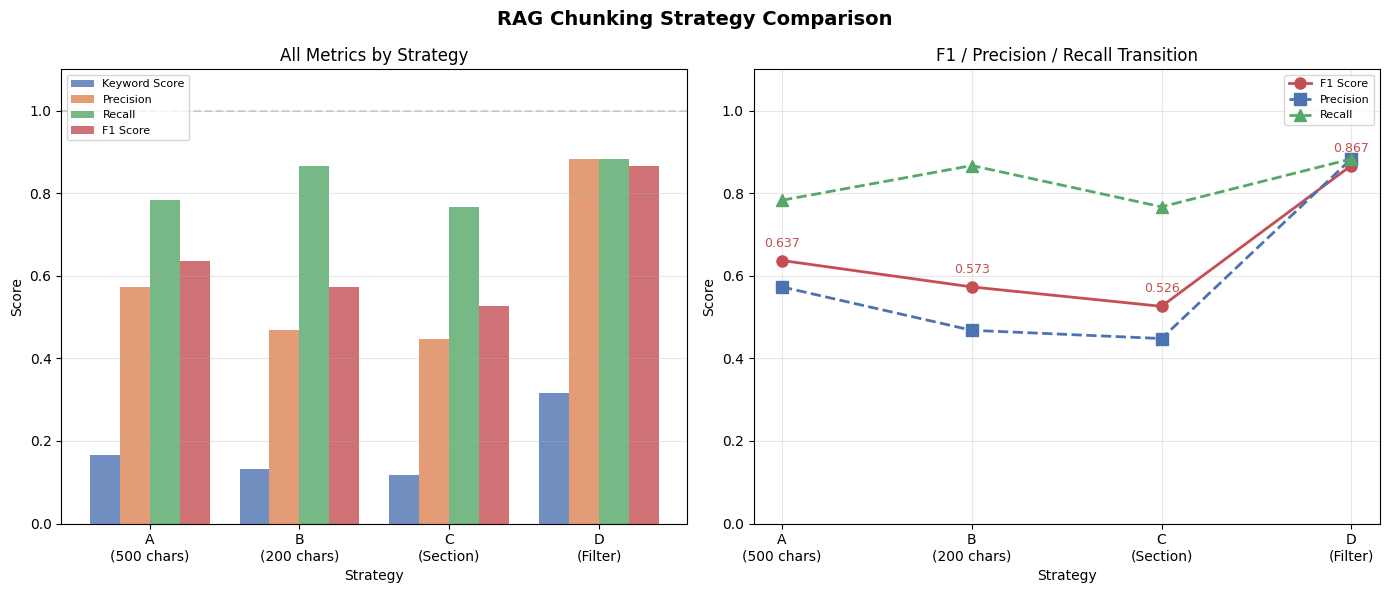

グラフを保存しました: /app/data/strategy_comparison.png
サマリーを保存しました: /app/data/phase5_summary.json


In [90]:
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 4戦略の結果をまとめる
strategies = {
    "A\n(500 chars)": {
        "keyword": 0.166, "precision": 0.573,
        "recall": 0.783, "f1": 0.637
    },
    "B\n(200 chars)": {
        "keyword": 0.133, "precision": 0.468,
        "recall": 0.867, "f1": 0.573
    },
    "C\n(Section)": {
        "keyword": 0.118, "precision": 0.448,
        "recall": 0.767, "f1": 0.526
    },
    "D\n(Filter)": {
        "keyword": 0.315, "precision": 0.883,
        "recall": 0.883, "f1": 0.867
    },
}

labels = list(strategies.keys())
metrics = ["keyword", "precision", "recall", "f1"]
metric_labels = ["Keyword Score", "Precision", "Recall", "F1 Score"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

x = range(len(labels))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("RAG Chunking Strategy Comparison", fontsize=14, fontweight="bold")

# 左：4指標の棒グラフ
ax1 = axes[0]
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [strategies[s][metric] for s in labels]
    offset = (i - 1.5) * width
    bars = ax1.bar(
        [xi + offset for xi in x],
        values,
        width,
        label=label,
        color=colors[i],
        alpha=0.8
    )

ax1.set_xlabel("Strategy")
ax1.set_ylabel("Score")
ax1.set_title("All Metrics by Strategy")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1.1)
ax1.legend(loc="upper left", fontsize=8)
ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
ax1.grid(axis="y", alpha=0.3)

# 右：F1スコアのみの折れ線グラフ
ax2 = axes[1]
f1_values = [strategies[s]["f1"] for s in labels]
precision_values = [strategies[s]["precision"] for s in labels]
recall_values = [strategies[s]["recall"] for s in labels]

ax2.plot(labels, f1_values, marker="o", linewidth=2,
         markersize=8, label="F1 Score", color="#C44E52")
ax2.plot(labels, precision_values, marker="s", linewidth=2,
         markersize=8, label="Precision", color="#4C72B0", linestyle="--")
ax2.plot(labels, recall_values, marker="^", linewidth=2,
         markersize=8, label="Recall", color="#55A868", linestyle="--")

for i, (f1, prec, rec) in enumerate(
    zip(f1_values, precision_values, recall_values)
):
    ax2.annotate(f"{f1:.3f}", (labels[i], f1),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color="#C44E52")

ax2.set_xlabel("Strategy")
ax2.set_ylabel("Score")
ax2.set_title("F1 / Precision / Recall Transition")
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()

# 保存
output_path = Path("/app/data/strategy_comparison.png")
plt.savefig(str(output_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"グラフを保存しました: {output_path}")

# 最終サマリーをJSONで保存
summary = {
    "strategies": {
        "A": {"description": "文字数ベース chunk_size=500 overlap=50",
              "avg_keyword_score": 0.166, "avg_precision": 0.573,
              "avg_recall": 0.783, "avg_f1": 0.637},
        "B": {"description": "文字数ベース chunk_size=200 overlap=20",
              "avg_keyword_score": 0.133, "avg_precision": 0.468,
              "avg_recall": 0.867, "avg_f1": 0.573},
        "C": {"description": "セクションベース分割",
              "avg_keyword_score": 0.118, "avg_precision": 0.448,
              "avg_recall": 0.767, "avg_f1": 0.526},
        "D": {"description": "セクションベース分割＋セクションフィルタ",
              "avg_keyword_score": 0.315, "avg_precision": 0.883,
              "avg_recall": 0.883, "avg_f1": 0.867},
    },
    "conclusion": "戦略D（セクションベース分割＋セクションフィルタ）が全指標で最良。"
                  "単純なチャンクサイズ変更（戦略B・C）は効果がなく、"
                  "メタデータを活用した検索設計が精度改善に有効であることが示された。"
}

summary_path = Path("/app/data/phase5_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"サマリーを保存しました: {summary_path}")